In [2]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [3]:
x = np.array( [1,2,3,4,5], np.float32)
y = np.array( [3,5,7,9,11], np.float32)

In [4]:
class MyDense:
    def __init__(self, units=1, input_dim=1):
        self.w = np.random.uniform([input_dim])
        self.b = np.random.uniform([units])

    def __call__(self, xd):
        hx = self.w*xd + self.b
        return hx
    def get_weights(self):
        return self.w, self.b
    
mydense = MyDense( units=1, input_dim=1)
print(mydense(x.reshape(-1,1))) # mydense.__call__(x.reshape(-1,1))
print(mydense.get_weights())

[[2.]
 [3.]
 [4.]
 [5.]
 [6.]]
(array([1.]), array([1.]))


In [5]:
# forward 연산 정의, w, b 정의 되었다.
# units : 라벨의 갯수
# input_dim : 특성 데이터의 갯수
dense = Dense( units=1, input_dim=1 ) 
dense( x.reshape(-1,1)) # forward hx = matmul(x,w) + b , hx = w*x + b


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[-1.2215855],
       [-2.443171 ],
       [-3.6647565],
       [-4.886342 ],
       [-6.1079273]], dtype=float32)>

In [6]:
w, b = dense.get_weights()
print(w)
print(b)

[[-1.2215855]]
[0.]


In [7]:
dense = Dense(units=1, input_dim=1)
model = Sequential( [dense] ) # dense의 w와 b가 학습 대상
model.compile( loss='mse', optimizer=Adam(0.1))
h = model.fit(x, y, epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - loss: 7.1343
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 5.0520
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 3.3422
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.0061
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.0355
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.4100
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0930
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0294
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1480
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.3680
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.6116
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.8167
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.9443
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.9800
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.9295
Epoch 16/500
1/1 ━

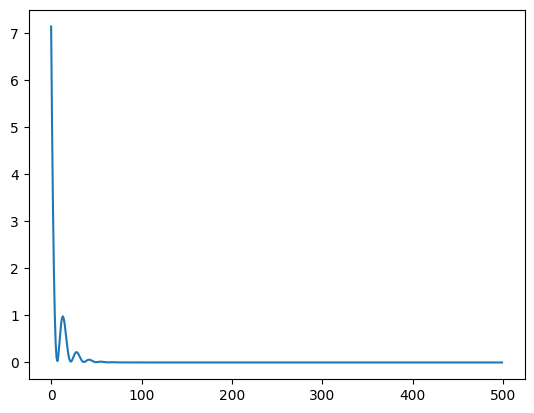

In [8]:
h.history['loss']
plt.plot(h.history['loss'])
plt.show()

In [9]:
w, b = dense.get_weights()
print(w)
print(b)

[[2.]]
[1.0000001]


In [10]:
dense(x.reshape(-1,1))

<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[ 3.],
       [ 5.],
       [ 7.],
       [ 9.],
       [11.]], dtype=float32)>

In [11]:
model.predict(x) # 값을 전처리(행렬변환), dense의 forward 호출

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[ 3.],
       [ 5.],
       [ 7.],
       [ 9.],
       [11.]], dtype=float32)

### 10분 퀴즈
cars.csv 케라스로 학습, 자동하 속도 20인 경우 제동거리를 예측하시오.

In [12]:
carDF = pd.read_csv('data/cars.csv', index_col='Unnamed: 0' )
carDF.head()

,speed,dist
1,4,2
2,4,10
3,7,4
4,7,22
5,8,16


In [13]:
x = carDF['speed'].values
y = carDF['dist'].values

In [14]:
dense = Dense(units=1, input_dim=1)
model = Sequential( [dense] ) # dense의 w와 b가 학습 대상
model.compile( loss='mse', optimizer=Adam(0.1))
model.fit(x, y, epochs=500)

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1223.3398 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1024.8352
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 854.5254 
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 707.1306
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 568.2281
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 467.8982
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 401.8937
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 344.3716
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 302.6862
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 278.3200
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 268.4953
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 268.2345
Epoch 13/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 269.3303
Epoch 14/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 272.7753
Epoch 15/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 278.22

In [15]:
model.predict(np.array([20])) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[60.95533]], dtype=float32)

In [16]:
w, b = dense.get_weights()
print(w)
print(b)

[[3.8275576]]
[-15.595816]


In [17]:
20*w + b

array([[60.95533]], dtype=float32)

In [18]:
y_pred = model.predict(x)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


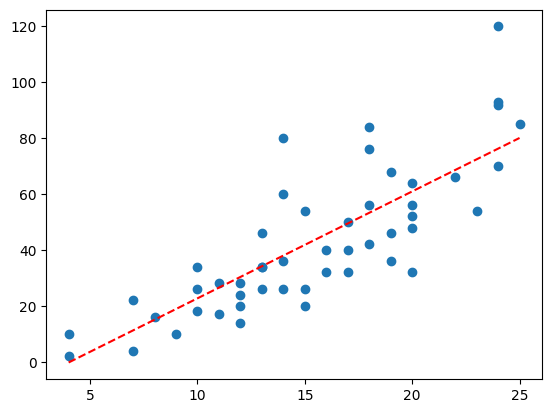

In [19]:
plt.scatter(x,y)
plt.plot( x, y_pred, 'r--')
plt.show()